# Primary wave-filter regions in omega-wavenumber space

This notebook plots the exact primary (`include_conjugates=False`) regions returned by `xr_ccew.make_filter_mask` for every built-in profile. The final panel compares resting mixed Rossby-gravity (MRG) filtering with a constant eastward background wind of $U=10$ m s$^{-1}$.

The first panels use the default resting-state Matsuno curves. A nonzero `background_u` Doppler-shifts every profile frequency bound into the observed frame; for a real inverse transform, `make_filter_mask` normally adds the corresponding `(-frequency, -wavenumber)` partner. That partner is omitted here so each named primary region remains easy to read.

The n=0 ER panel follows the implementation's rectangular fallback when no finite ER curve is available over its supplied wavenumber range.

In [1]:
from __future__ import annotations

import os
import sys
import tempfile
from pathlib import Path

repo_root = next(
    (
        candidate
        for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "xr_ccew").exists()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError("run this notebook from inside the xr_ccew repository")
sys.path.insert(0, str(repo_root / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "xr_ccew_matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.patches import Patch

import xr_ccew as tw

In [2]:
frequency = np.linspace(-0.45, 1.05, 601)
wavenumber = np.linspace(-22.0, 15.0, 741)
spectral_grid = xr.DataArray(
    np.zeros((frequency.size, wavenumber.size)),
    dims=("frequency", "zonal_wavenumber"),
    coords={"frequency": frequency, "zonal_wavenumber": wavenumber},
)

def filter_region(profile, *, background_u=0.0):
    return tw.make_filter_mask(
        spectral_grid,
        profile,
        include_conjugates=False,
        background_u=background_u,
    )

profiles = tw.wave_profiles("all")
resting_regions = {profile.name: filter_region(profile) for profile in profiles}
mrg_profile = tw.wave_profile("MRG")
mrg_u10_region = filter_region(mrg_profile, background_u=10.0)

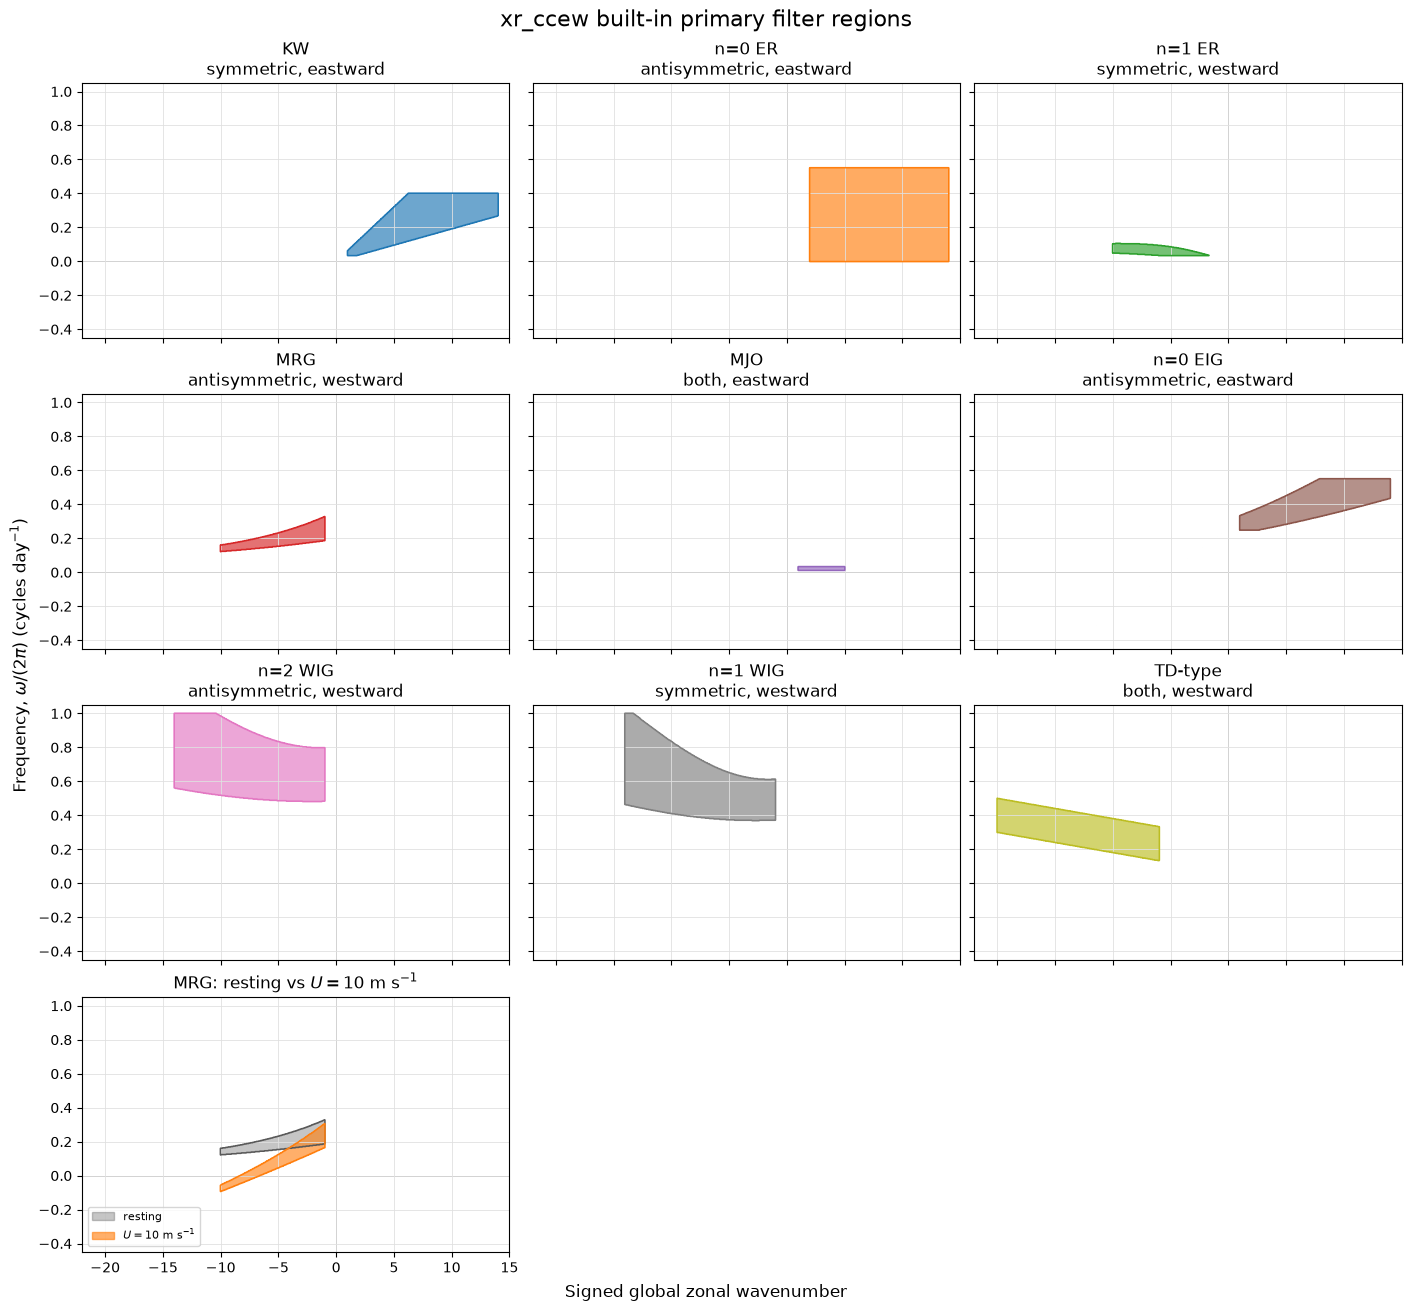

In [3]:
def draw_region(ax, region, color, *, alpha=0.65):
    values = region.transpose("frequency", "zonal_wavenumber").values.astype(int)
    ax.contourf(
        wavenumber,
        frequency,
        values,
        levels=[0.5, 1.5],
        colors=[color],
        alpha=alpha,
    )
    ax.contour(
        wavenumber,
        frequency,
        values,
        levels=[0.5],
        colors=[color],
        linewidths=1.15,
    )

n_columns = 3
n_panels = len(profiles) + 1
n_rows = int(np.ceil(n_panels / n_columns))
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(14, 3.25 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.ravel(axes)
colors = plt.get_cmap("tab10").colors

for index, (profile, ax) in enumerate(zip(profiles, axes)):
    draw_region(ax, resting_regions[profile.name], colors[index % len(colors)])
    ax.set_title(f"{profile.name}\n{profile.symmetry}, {profile.direction}")

overlay_ax = axes[len(profiles)]
draw_region(overlay_ax, resting_regions[mrg_profile.name], "0.35", alpha=0.35)
draw_region(overlay_ax, mrg_u10_region, "tab:orange", alpha=0.62)
overlay_ax.set_title("MRG: resting vs $U=10$ m s$^{-1}$")
overlay_ax.legend(
    handles=[
        Patch(facecolor="0.35", edgecolor="0.35", alpha=0.35, label="resting"),
        Patch(facecolor="tab:orange", edgecolor="tab:orange", alpha=0.62, label="$U=10$ m s$^{-1}$"),
    ],
    loc="lower left",
    fontsize=8,
)

for ax in axes:
    ax.axhline(0.0, color="0.5", linewidth=0.6, zorder=0)
    ax.axvline(0.0, color="0.5", linewidth=0.6, zorder=0)
    ax.set(xlim=(-22, 15), ylim=(-0.45, 1.05))
    ax.grid(color="0.88", linewidth=0.6)
for ax in axes[n_panels:]:
    ax.set_visible(False)

fig.suptitle("xr_ccew built-in primary filter regions", fontsize=16)
fig.supxlabel("Signed global zonal wavenumber")
fig.supylabel("Frequency, $\\omega/(2\\pi)$ (cycles day$^{-1}$)")
plt.show()

For the shifted MRG region, the observed frequency is $f_{obs}=f_{Matsuno}+U s\,86400/\mathrm{perimeter}$. MRG is westward (`s < 0`), so an eastward mean wind shifts it toward lower frequency; part of the $U=10$ m s$^{-1}$ region consequently crosses zero observed frequency. This is expected for the constant-zonal-advection approximation.